In [10]:
#Importing necessary libraries
from google.colab import drive

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency

In [11]:
train_data= pd.read_csv("https://raw.githubusercontent.com/ashfiqunmustari/Titanic-EDA/main/Dataset/train.csv")
test_data = pd.read_csv("https://raw.githubusercontent.com/ashfiqunmustari/Titanic-EDA/main/Dataset/test.csv")


In [12]:
print(train_data.head(10))

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   
5            6         0       3   
6            7         0       1   
7            8         0       3   
8            9         1       3   
9           10         1       2   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   
5                                   Moran, Mr. James    male   NaN      0   
6                            McCarthy, Mr. Timothy J    male  54

In [13]:
print(test_data.head(10))

   PassengerId  Pclass                                          Name     Sex  \
0          892       3                              Kelly, Mr. James    male   
1          893       3              Wilkes, Mrs. James (Ellen Needs)  female   
2          894       2                     Myles, Mr. Thomas Francis    male   
3          895       3                              Wirz, Mr. Albert    male   
4          896       3  Hirvonen, Mrs. Alexander (Helga E Lindqvist)  female   
5          897       3                    Svensson, Mr. Johan Cervin    male   
6          898       3                          Connolly, Miss. Kate  female   
7          899       2                  Caldwell, Mr. Albert Francis    male   
8          900       3     Abrahim, Mrs. Joseph (Sophie Halaut Easu)  female   
9          901       3                       Davies, Mr. John Samuel    male   

    Age  SibSp  Parch     Ticket     Fare Cabin Embarked  
0  34.5      0      0     330911   7.8292   NaN        Q  
1

**Data Cleaning**

In [14]:
#Checking which features have missing values in training data
print("Number of missing values in training data:")
print(train_data.isnull().sum())

Number of missing values in training data:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [15]:
#Checking which features have missing values in test data
print("Number of missing values in test data:")
print(test_data.isnull().sum())

Number of missing values in test data:
PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


In [16]:
#Finding the median age
median_age= train_data['Age'].median()
print(median_age)

28.0


To handle missing age values, it is efficient to replace them with the median age because the median provides a central value that accurately represents the data while maintaining the overall distribution of ages.  Also, The median is less affected by outliers. The age distribution here has extreme values such as child of age 2, using the median ensures that these outliers do not skew the data.

In [ ]:
#Replacing all the missing age values with median age
train_data['Age'].fillna(median_age, inplace=True)
test_data['Age'].fillna(median_age, inplace=True)

Since the cabin number is not numerical data, we cannot calculate the mean or median. Replacing missing values with the mode (the most common cabin number) could skew the data. So I am replacing the missing cabin values with "Unknown."

In [ ]:
#Replacing all the missing cabin name as unknown
train_data['Cabin'].fillna('Unknown', inplace=True)
test_data['Cabin'].fillna('Unknown', inplace=True)

Here are only 2 rows with missing Port of Embarkation, so i will drop them as it will have a very minimal impact on the dataset size

In [19]:
#Dropping the 2 rows in training data where the embarked feature has missing value
train_data= train_data[train_data['Embarked'].notnull()]

There is only one row in the test dataset with a missing fare value. Since calculating the median is easy and effective, I will replace the missing value with the median instead of dropping the row.

In [ ]:
#Replacing the missing fare value in the test data with median fare
median_fare= train_data['Fare'].median()
test_data['Fare'].fillna(median_fare, inplace=True)

In [21]:
#Checking the number of missing values after handling
print("Number of missing values in training data:")
print(train_data.isnull().sum())

Number of missing values in training data:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


In [22]:
#Checking the number of missing values after handling
print("Number of missing values in test data:")
print(test_data.isnull().sum())

Number of missing values in test data:
PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


In [23]:
print("Number of rows in train data:", len(train_data))
print("Number of rows in test data:", len(test_data))

#Checking if there is any duplicated rows
duplicates1 = train_data.duplicated().sum()
duplicates2 = test_data.duplicated().sum()
print("Number of duplicated rows in training data: ",duplicates1)
print("Number of duplicated rows in test data: ",duplicates2)

Number of rows in train data: 889
Number of rows in test data: 418
Number of duplicated rows in training data:  0
Number of duplicated rows in test data:  0


In [24]:
#Checking the data types to see if there is any date related data
print("Data types:", train_data.dtypes)

Data types: PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [25]:
#Creating a new column for the passenger's age group
train_data["Age Group"]=0
test_data["Age Group"]=0

In [ ]:
#Assigning age group depending on the age value
def assign_ageGroup(age):
    if age<18:
        return 'Child'
    elif age>=18 and age<50:
        return 'Adult'
    else:
        return 'Senior'

for i, row in train_data.iterrows():
    train_data.at[i,"Age Group"] = assign_ageGroup(train_data.at[i,"Age"])

for j, row in test_data.iterrows():
    test_data.at[j,"Age Group"] = assign_ageGroup(test_data.at[j,"Age"])

In [27]:
#Checking the training data after adding a new feature
print(train_data.head(10))

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   
5            6         0       3   
6            7         0       1   
7            8         0       3   
8            9         1       3   
9           10         1       2   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   
5                                   Moran, Mr. James    male  28.0      0   
6                            McCarthy, Mr. Timothy J    male  54

In [28]:
#Checking the test data after adding a new feature
print(test_data.head(10))

   PassengerId  Pclass                                          Name     Sex  \
0          892       3                              Kelly, Mr. James    male   
1          893       3              Wilkes, Mrs. James (Ellen Needs)  female   
2          894       2                     Myles, Mr. Thomas Francis    male   
3          895       3                              Wirz, Mr. Albert    male   
4          896       3  Hirvonen, Mrs. Alexander (Helga E Lindqvist)  female   
5          897       3                    Svensson, Mr. Johan Cervin    male   
6          898       3                          Connolly, Miss. Kate  female   
7          899       2                  Caldwell, Mr. Albert Francis    male   
8          900       3     Abrahim, Mrs. Joseph (Sophie Halaut Easu)  female   
9          901       3                       Davies, Mr. John Samuel    male   

    Age  SibSp  Parch     Ticket     Fare    Cabin Embarked Age Group  
0  34.5      0      0     330911   7.8292  Unkn

**Data Exploratory Data Analysis**

An overview of the passangers age group:
Age Group
Adult     703
Child     113
Senior     73
Name: count, dtype: int64


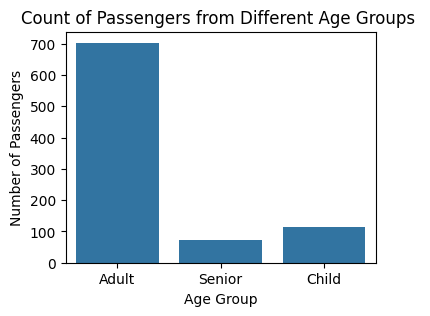

In [29]:
AgeGroupBasedCount=train_data['Age Group'].value_counts()
print("An overview of the passangers age group:")
print(AgeGroupBasedCount)

plt.figure(figsize=(4, 3))
sns.countplot(x='Age Group', data=train_data)

plt.xticks(ticks=[0, 1, 2], labels=['Adult', 'Senior', 'Child'])
plt.title('Count of Passengers from Different Age Groups ')
plt.xlabel('Age Group')
plt.ylabel('Number of Passengers')

plt.show()

An overview of the number of passangers from each port:
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


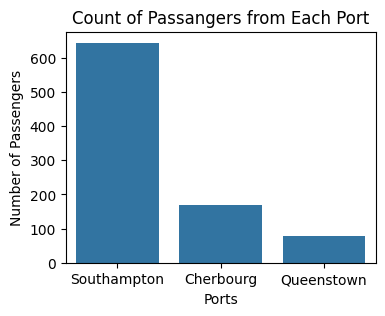

In [30]:
PortBasedCount=train_data['Embarked'].value_counts()
print("An overview of the number of passangers from each port:")
print(PortBasedCount)

plt.figure(figsize=(4, 3))
sns.countplot(x='Embarked', data=train_data)

plt.xticks(ticks=[0, 1, 2], labels=['Southampton', 'Cherbourg', 'Queenstown'])
plt.title('Count of Passangers from Each Port')
plt.xlabel('Ports')
plt.ylabel('Number of Passengers')

plt.show()

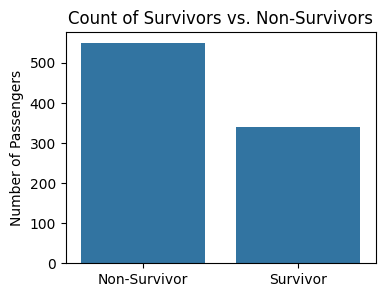

In [31]:
plt.figure(figsize=(4, 3))
sns.countplot(x='Survived', data=train_data)

plt.xticks(ticks=[0, 1], labels=['Non-Survivor', 'Survivor'])
plt.title('Count of Survivors vs. Non-Survivors')
plt.xlabel('')
plt.ylabel('Number of Passengers')

plt.show()

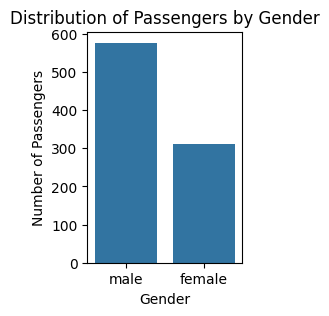

In [32]:
#Visualization of the distribution of passengers by gender using a bar plot
GenderBasedCount=train_data['Sex'].value_counts()

plt.figure(figsize=(2, 3))
sns.barplot(x=GenderBasedCount.index, y=GenderBasedCount.values)

plt.title('Distribution of Passengers by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Passengers')

plt.show()

**Interpretation:** The bar plot shows that there were more male passengers than female passengers in the ship

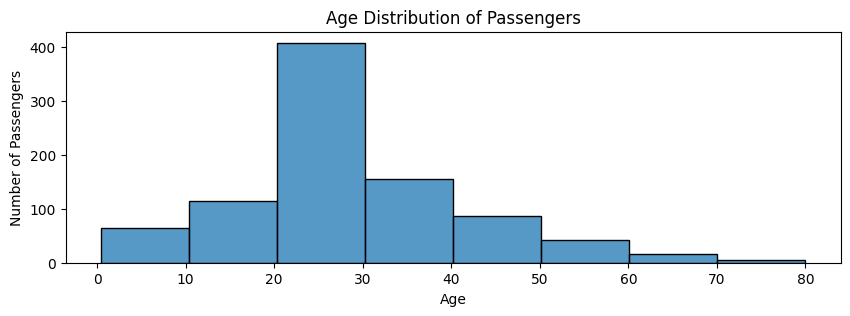

In [33]:
#histogram for the age distribution
plt.figure(figsize=(10, 3))
sns.histplot(data=train_data["Age"],bins=8)

plt.title('Age Distribution of Passengers')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')

plt.show()

**Interpretation:**The age distribution histrogram shows that most passengers, nearly 400, were between the ages of 21 and 31.

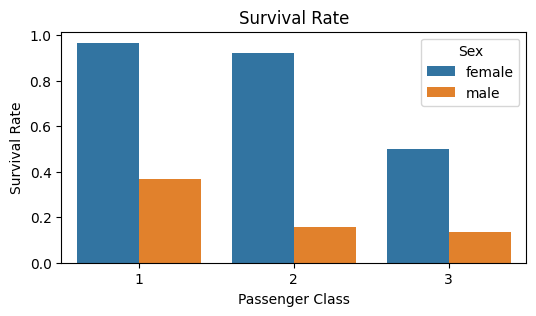

In [34]:
#Visualizion of the survival rate by gender and class
survival_rate = train_data.groupby(['Pclass', 'Sex'])['Survived'].mean().reset_index()

plt.figure(figsize=(6, 3))
sns.barplot(data=survival_rate, x='Pclass', y='Survived', hue='Sex')

plt.title('Survival Rate')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')

plt.show()

**Interpretation:** The bar plots show that female passengers had a significantly higher survival rate than male passengers. Besides, survival rates were highest for both female and male passenger in first class, with the lowest survival rates in third class.

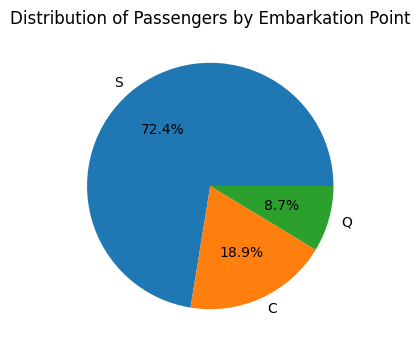

In [35]:
embarked_counts = train_data['Embarked'].value_counts()
plt.figure(figsize=(4, 4))
plt.pie(embarked_counts, labels=embarked_counts.index, autopct='%1.1f%%')
plt.title('Distribution of Passengers by Embarkation Point')

plt.show()


  Embarked  Survived
0        C  0.553571
1        Q  0.389610
2        S  0.336957


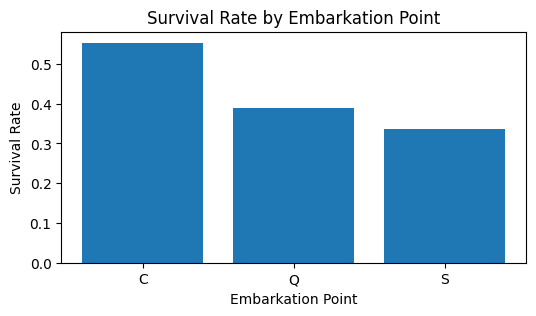

In [36]:
survival_rate2 = train_data.groupby('Embarked')['Survived'].mean().reset_index()
print(survival_rate2)

plt.figure(figsize=(6, 3))
plt.bar(survival_rate2['Embarked'], survival_rate2['Survived'])

plt.title('Survival Rate by Embarkation Point')
plt.xlabel('Embarkation Point')
plt.ylabel('Survival Rate')

plt.show()

**Interestingly,** although the majority of passengers(72.4%) embarked from Southampton(S), this port had the lowest survival rate, with only 33.7% surviving. In contrast, while only 18.9% of passengers embarked from Cherbourg(C), more than 50% of them survived. It shows a significant difference in survival rates based on Port of Embarkation.

**Basic Statistical Analysis**

In [37]:
#Calculating the mean, median, and mode for the 'Fare' column
mean_fare= train_data["Fare"].mean()
print("Mean Fare of Trainning Data:",round(mean_fare, 2))

median_fare= train_data["Fare"].median()
print("Median Fare of Trainning Data:",round(median_fare, 2))

mode_fare= train_data["Fare"].mode()[0]
print("Mode Fare of Trainning Data:",round(mode_fare, 2))

Mean Fare of Trainning Data: 32.1
Median Fare of Trainning Data: 14.45
Mode Fare of Trainning Data: 8.05


**Interpretation:** It shows that the average fare is high (32.1). But most passengers actually paid lower amounts, as the median is 14.45. Also, the mode is 8.05, which means the fare distribution is skewed.

In [38]:
#Calculating the mean, median, and mode for the 'Age' column
mean_age= int(train_data["Age"].mean())
print("Mean Age of Trainning Data:",mean_age)

median_age= int(train_data["Age"].median())
print("Median Age of Trainning Data:",median_age)

mode_age= int(train_data["Age"].mode()[0])
print("Mode Age of Trainning Data:",mode_age)

Mean Age of Trainning Data: 29
Median Age of Trainning Data: 28
Mode Age of Trainning Data: 28


**Interpretation:** As the mean age is 29, most passengers are in the adult age group. The mean and median are close which indicates a normal age distribution without significant outliers. The mode at 28 suggests this is a common age among the passengers.

In [39]:
#Performing a t-test to determine if there's a significant difference in survival rate based on gender

#Separating the survived passengers based on gender
survived_male = train_data[train_data['Sex'] == 'male']['Survived']
survived_female = train_data[train_data['Sex'] == 'female']['Survived']

#Performing a t-test
t,p = ttest_ind(survived_male, survived_female)

print("T-statistic:",t)
print("P-value:",p)

T-statistic: -19.18735865612515
P-value: 6.682012140613411e-69


**Interpretation:**
T-statistic is a measure of how different the means of male and female passengers are compared to the variability of the data.

Here -19.19 is very large which indicates a large difference.

The P value here is far below 0.05 which shows there's a significant difference in survival rate based on gender.

As the T value is negative, we can determine that the female group has a larger survival rate than the the male group.

In [40]:
#Performing a chi-square test
contingency_table = pd.crosstab(train_data['Age Group'], train_data['Survived'])
p2= chi2_contingency(contingency_table)[1]
print("P value is:",p2)

P value is: 0.0011259639814285567


**Interpretation**: As the P-value is below 0.05, it means a significant difference in survival rate among age groups.

In [41]:
survival_rate_by_ageGroup = contingency_table.div(contingency_table.sum(axis=1), axis=0)
print("Survival Rates by Age Group:\n", survival_rate_by_ageGroup[1])

Survival Rates by Age Group:
 Age Group
Adult     0.359886
Child     0.539823
Senior    0.356164
Name: 1, dtype: float64


**Interpretation:** We can observe a very close survival rate among adults and seniors, but a significantly better survival rate in the child age group where more than 50% children survived.